# Проєкт: Кластеризація клієнтів (RFM-аналіз) на даних Olist

Оскільки я працюю в ecommerce, вирішив виконати наступну задачу.
Датасет -  бразильський E-commerce датасет (Olist), що містить інформацію про понад 99 тис. замовлень - https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
Завдання - провести клієнтську сегментацію на основі купівельної поведінки за допомогою методології RFM:
* Recency -  кількість днів з моменту останньої покупки.
* Frequency - кількість замовлень, зроблених клієнтом.
* Monetary - загальна сума грошей, витрачена клієнтом.

Мета - озділити клієнтів на однорідні групи. Це дозволить бізнесу виявити VIP-клієнтів, новачків, потенційний churn та оптимізувати маркетингові кампанії.



In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import os
import warnings

warnings.filterwarnings('ignore')

path = '/Users/admin/Downloads/archive (3)/' 

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')

translations = pd.read_csv(path + 'product_category_name_translation.csv')

# Деномралізація
df = pd.merge(orders, customers, on='customer_id', how='left')
df = pd.merge(df, items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')
df = pd.merge(df, translations, on='product_category_name', how='left')
df = pd.merge(df, sellers, on='seller_id', how='left')
df = pd.merge(df, payments, on='order_id', how='left')
df = pd.merge(df, reviews, on='order_id', how='left')

# Portuguese -> English
if 'product_category_name' in df.columns and 'product_category_name_english' in df.columns:
    df = df.drop('product_category_name', axis=1)

display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


## Очистка даних

In [34]:
# Без ID клієнта, дати покупки або суми платежу RFM-аналіз неможливий.
critical_cols = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']
df = df.dropna(subset=critical_cols)

# Залишаємо лише успішно доставлені замовлення.
df = df[df['order_status'] == 'delivered']

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [35]:
orders.shape

(99441, 8)

In [36]:
df.shape

(115720, 39)

Зростання кількості рядків у фінальному датасеті порівняно з оригінальною таблицею замовлень (olist_orders_dataset) зумовлене наявністю зв’язків типу one-to-many між сутностями.

- Одне замовлення може містити кілька товарів (order_items).
- Оплата за одне замовлення може здійснюватися кількома транзакціями або методами (order_payments).
- Одне замовлення може мати декілька записів у відгуках (order_reviews).

Під час виконання операції pd.merge() замовлення дублюється для кожної унікальної комбінації дочірніх записів, щоб представити дані в денормалізованому (пласкому) форматі.
Дослідімо дублікати.

In [37]:
# Дропаємо дублікати по комбінації замовлення + номер платежу, щоб не задвоїти суми.
payments_clean = df.drop_duplicates(subset=['order_id', 'payment_sequential', 'payment_value'])

# Визначаємо "сьогоднішню" дату для аналізу (остання транзакція + 1 день)
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Рахуємо recency та frequency
rf_df = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique')
).reset_index()

# Рахуємо monetary 
m_df = payments_clean.groupby('customer_unique_id').agg(
    Monetary=('payment_value', 'sum')
).reset_index()

rfm = pd.merge(rf_df, m_df, on='customer_unique_id', how='inner')

# Видалення викидів 
q99 = rfm['Monetary'].quantile(0.99)
rfm_clean = rfm[(rfm['Monetary'] <= q99) & (rfm['Monetary'] > 0)]

In [43]:
rfm_clean.head(3)

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22


In [42]:
rfm_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92423 entries, 0 to 93356
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  92423 non-null  object 
 1   Recency             92423 non-null  int64  
 2   Frequency           92423 non-null  int64  
 3   Monetary            92423 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.5+ MB


In [45]:
rfm_clean.nunique()

customer_unique_id    92423
Recency                 610
Frequency                 8
Monetary              27409
dtype: int64

## EDA

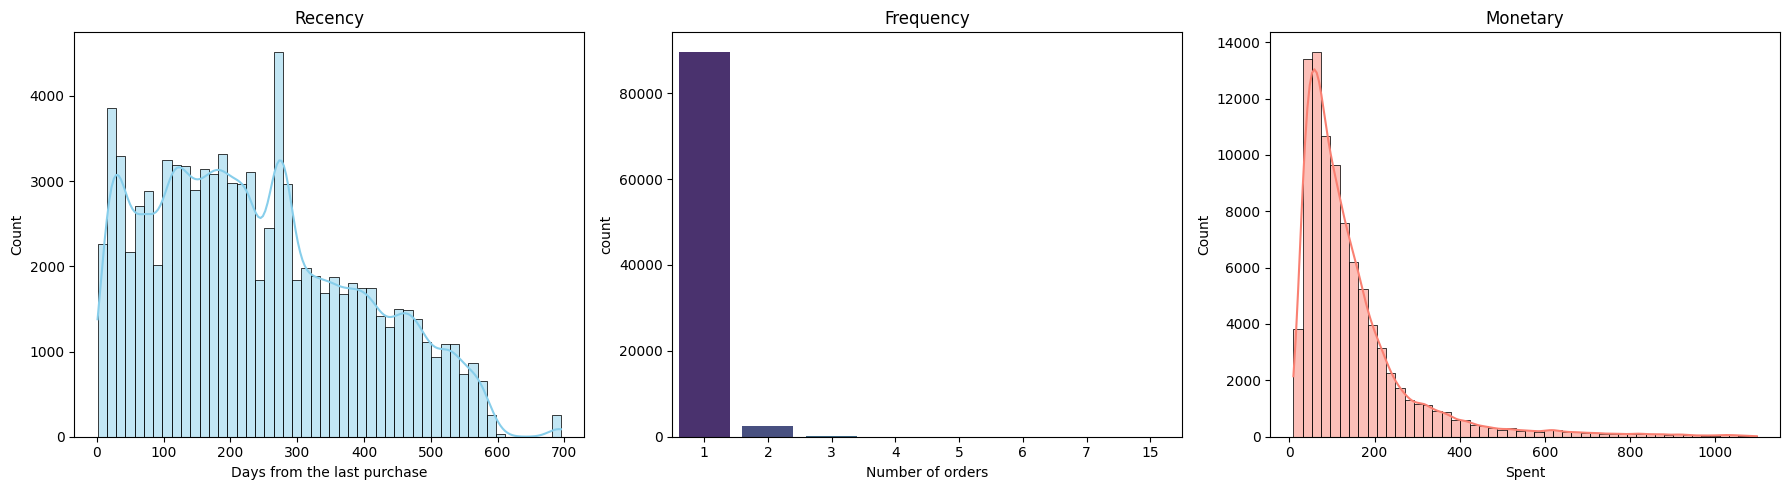

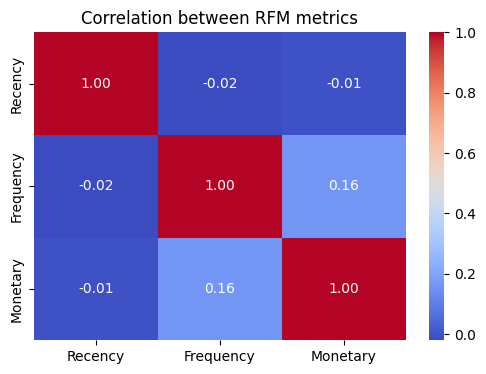

In [53]:
# Візуалізація розподілу RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_clean['Recency'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency')
axes[0].set_xlabel('Days from the last purchase')

sns.countplot(x='Frequency', data=rfm_clean, ax=axes[1], palette='viridis')
axes[1].set_title('Frequency')
axes[1].set_xlabel('Number of orders')

sns.histplot(rfm_clean['Monetary'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Monetary')
axes[2].set_xlabel('Spent')

plt.tight_layout()
plt.show()

# Матриця кореляцій
plt.figure(figsize=(6, 4))
sns.heatmap(rfm_clean[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between RFM metrics')
plt.show()

1. Recency - розподіл має кілька піків, що свідчить про хвилеподібний приплив клієнтів (можливо, пов'язано зі святами або маркетинговими кампаніями). Більшість клієнтів робили покупки від 100 до 300 днів тому.
2. Frequency - це типова картина для багатьох ритейлерів — абсолютна більшість клієнтів (понад 90%) зробили лише одне замовлення. Це означає, що магазин має великі проблеми з утриманням клієнтів.
3. Monetary - розподіл сильно зміщений вправо (Right-skewed). Більшість чеків знаходяться в діапазоні до 200 реалів, але є невелика кількість клієнтів з чеками на 1000-2000 реалів.
4. Кореляція - між частотою (F) та грошима (M) є позитивна кореляція (0.40), що логічно: чим частіше людина купує, тим вищий її загальний чек.

## Кластеризація

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Логарифмування + стандартизація
rfm_log = rfm_clean[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Оскільки Agglomerative Clustering вимагає багато пам'яті (O(N^2)), то використаємо випадкову підвибірку 15 000 клієнтів для чесного порівняння всіх 3 методів
np.random.seed(42)
indices = np.random.choice(len(rfm_scaled), 15000, replace=False)
X_sample = rfm_scaled[indices]
rfm_sample = rfm_clean.iloc[indices].copy()

# Використаємо k=4 кластери, як стандарт для RFM
n_clusters = 4
models = {
    "K-Means": KMeans(n_clusters=n_clusters, random_state=42),
    "Gaussian Mixture": GaussianMixture(n_components=n_clusters, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=n_clusters)
}

results = []

print("Starting fitting 3 models\n")
for name, model in models.items():
    labels = model.fit_predict(X_sample)
    rfm_sample[f'Cluster_{name}'] = labels
    
    sil_score = silhouette_score(X_sample, labels)
    db_score = davies_bouldin_score(X_sample, labels)
    
    results.append({'Method': name, 'Silhouette Score': sil_score, 'Davies-Bouldin': db_score})
    print(f"Method {name} done.")

df_results = pd.DataFrame(results)
display(df_results.sort_values(by='Silhouette Score', ascending=False))

Starting fitting 3 models

Method K-Means done.
Method Gaussian Mixture done.
Method Agglomerative done.


,Method,Silhouette Score,Davies-Bouldin
0,K-Means,0.400047,0.742801
1,Gaussian Mixture,0.393302,0.752721
2,Agglomerative,0.330545,0.871043


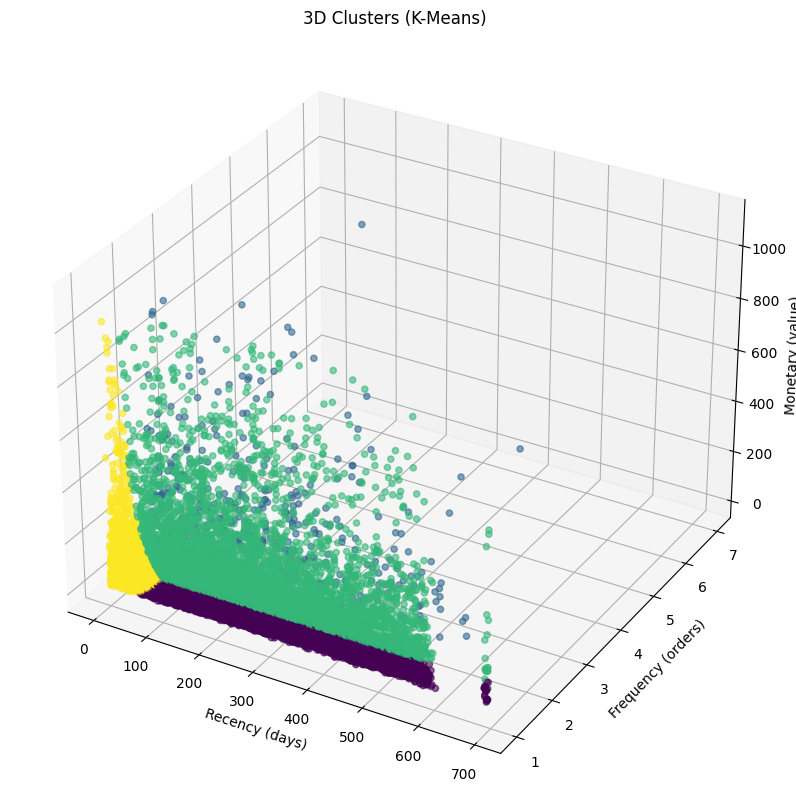

,Mean Recency,Mean Frequency,Mean Monetary,Сlient number
Cluster_K-Means,,,,
0,283.1,1.0,63.4,6367
1,217.0,2.1,284.5,418
2,273.4,1.0,242.0,5757
3,39.8,1.0,129.3,2458


In [52]:
# Візуалізація 3D розсіювання для K-Means
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm_sample['Recency'], 
                     rfm_sample['Frequency'], 
                     rfm_sample['Monetary'], 
                     c=rfm_sample['Cluster_K-Means'], 
                     cmap='viridis', s=20, alpha=0.6)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (value)')
ax.set_title('3D Clusters (K-Means)')
plt.show()

# Профілювання
cluster_profile = rfm_sample.groupby('Cluster_K-Means').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_profile.columns = ['Mean Recency', 'Mean Frequency', 'Mean Monetary', 'Сlient number']
display(cluster_profile)

В ході експерименту було застосовано 3 методи кластеризації:
1. K-Means: центроїдний метод, який добре працює з кулястими скупченнями.
2. Gaussian Mixture Model (GMM): імовірнісний метод, який дозволяє кластерам мати еліптичну форму.
3. Agglomerative Clustering: ієрархічний метод з підходом знизу-вгору.

Метрики оцінки:
* Silhouette Score (чим ближче до 1, тим краще): оцінює щільність кластерів та їх віддаленість один від одного. 
* Davies-Bouldin Index (чим ближче до 0, тим краще): оцінює співвідношення внутрішньокластерного розкиду до відстані між центрами кластерів.

Результати: найоптимальнішим методом виявився K-Means. Він показав найвищий Silhouette Score та найнижчий Davies-Bouldin Index. Крім того, K-Means є найшвидшим (ефективним) з точки зору обчислювальних ресурсів для таких об'ємів даних.

### Фінальні висновки
K-Means розділив клієнтів на 4 бізнес-сегменти, які легко інтерпретувати:
* Нові клієнти з високим чеком: нещодавно зробили покупку на значну суму - їм варто запропонувати програму лояльності.
* Сплячі клієнти: купували дуже давно і на невеликі суми - итрачати багато маркетингового бюджету на них недоцільно.
* Лояльні: найчастіше купують і приносять стабільний дохід - їм потрібен найкращий сервіс та ексклюзивні пропозиції.
* Одноразові з низьким чеко: купили давно і дешево. 

Завдяки нормалізації даних алгоритм K-Means зміг знайти математично обґрунтовані межі навіть у даних, де 90% клієнтів зробили лише одну покупку.